Bem-vindo(a) ao sistema de monitoramento, a!
╔══════════════════════════════════════════╗
             MENU PRINCIPAL                
╚══════════════════════════════════════════╝
[0] - Finalizar Execução do Sistema
[1] - Cadastrar / Adicionar Novo Som
[2] - Simular Detecção de Áudio (Câmera e HUD Tátil) 
[3] - Acessar Painel de Descobertas (Relatório Semanal de Autonomia)  
[4] - Configurar Intensidade da Vibração (Motor Háptico)

Redirecionando para a opção 3...

[1] - Ver registros de sons [2] - Ver Registros de histórico de alertas
       Som Intensidade
0   Alarme        Alta
1   Música        Alta
2   Passos       Baixa
3  Trafego       Média
4    Carro        Alto
5    Carro        Alto
6    Carro        Alto
7        a           a
8     Moto       Médio


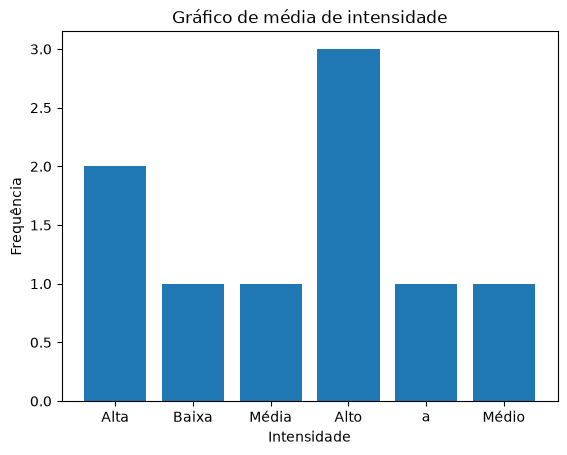

╔══════════════════════════════════════════╗
             MENU PRINCIPAL                
╚══════════════════════════════════════════╝
[0] - Finalizar Execução do Sistema
[1] - Cadastrar / Adicionar Novo Som
[2] - Simular Detecção de Áudio (Câmera e HUD Tátil) 
[3] - Acessar Painel de Descobertas (Relatório Semanal de Autonomia)  
[4] - Configurar Intensidade da Vibração (Motor Háptico)

Redirecionando para a opção 3...

[1] - Ver registros de sons [2] - Ver Registros de histórico de alertas
                                 Historico_Alerta          Direção Ângulo
0  Som detectado a 240° vindo de Oeste (Esquerda)          Direita    90°
1   Som detectado a 120° vindo de Leste (Direita)  Leste (Direita)    120
2     Som detectado a 10° vindo de Norte (Frente)   Norte (Frente)     10


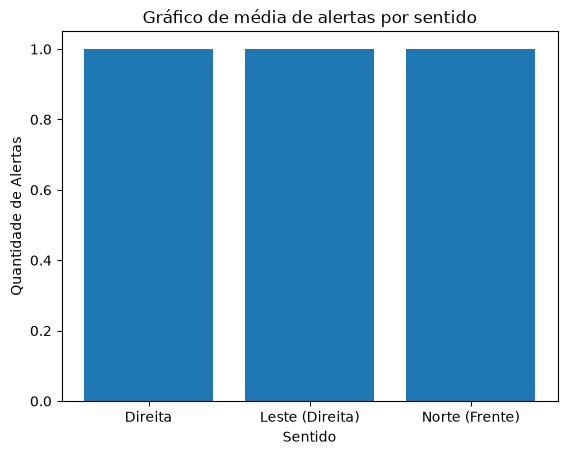

╔══════════════════════════════════════════╗
             MENU PRINCIPAL                
╚══════════════════════════════════════════╝
[0] - Finalizar Execução do Sistema
[1] - Cadastrar / Adicionar Novo Som
[2] - Simular Detecção de Áudio (Câmera e HUD Tátil) 
[3] - Acessar Painel de Descobertas (Relatório Semanal de Autonomia)  
[4] - Configurar Intensidade da Vibração (Motor Háptico)

Fim!



In [ ]:
## SPRINT 3 - PROJETO VIZUALIZANDO O SOM##
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter 

class Usuario:

    def __init__(self, Nome):
        self.Nome = Nome

    def dar_boas_vindas (self):
        return f"Bem-vindo(a) ao sistema de monitoramento, {self.Nome}!"



def exibir_painel_interativo():
        print(f"""╔══════════════════════════════════════════╗
             MENU PRINCIPAL                
╚══════════════════════════════════════════╝
[0] - Finalizar Execução do Sistema
[1] - Cadastrar / Adicionar Novo Som
[2] - Simular Detecção de Áudio (Câmera e HUD Tátil) 
[3] - Acessar Painel de Descobertas (Relatório Semanal de Autonomia)  
[4] - Configurar Intensidade da Vibração (Motor Háptico)""")


sons_pandas = [{"Som": "Alarme", "Intensidade": "Alta"}]
historico_pandas = [{"Historico_Alerta" : "Som detectado a 240° vindo de Oeste (Esquerda)", 
                    "Direção" : "Direita",
                    "Ângulo" : "90°"}]


try:
    df_frequencia_sons = pd.read_csv("sons_cadastrados.csv")
    sons_pandas = df_frequencia_sons.to_dict(orient="records")
except FileNotFoundError:
    pass


def cadastrar_som():
    while True:
        print("Redirecionando para a opção 1...")

        print("Insira o som que deseja registrar: ")
        som = input()
        print(som)

        print("Insira a intensidade do som que deseja registrar: ")
        intensidade = input()
        print(intensidade)

        if som.replace(" ", "").isalpha() and intensidade.replace(" ", "").isalpha():
            break 
        else:
            print("Erro: Digite apenas nomes de texto, sem números!")

    sons_pandas.append({
    "Som": som, 
    "Intensidade": intensidade
    })

    df = pd.DataFrame(sons_pandas)
    df.to_csv("sons_cadastrados.csv", index=False, encoding="utf-8")
    print(sons_pandas)

try:
    df_direcao_sons = pd.read_csv("historico_alertas.csv") 
    historico_pandas = df_direcao_sons.to_dict(orient="records")
except FileNotFoundError:
    pass

def simular_audio():
     print("Redirecionando para a opção 2...")

     print("Insira o ângulo que deseja registrar: ")

     try:
            angulo = int(input("\nDigite o Ângulo do som (0°-360°)"))
            if angulo < 0 or angulo > 360:
                print("Digite um ângulo de 0° a 360°.")
                return

            if angulo >= 45 and angulo <135:
                direcao = "Leste (Direita)"
            elif angulo >= 135 and angulo <225:
                direcao = "Sul(Atrás)"
            elif angulo >= 225 and angulo < 315:
                direcao = "Oeste (Esquerda)"
            else:
                direcao = "Norte (Frente)"

            alerta = f"Som detectado a {angulo}° vindo de {direcao}"
            print(alerta)

            historico_pandas.append({
                "Historico_Alerta": alerta, 
                "Direção": direcao,
                "Ângulo": angulo
            })

            df = pd.DataFrame(historico_pandas)
            df.to_csv("historico_alertas.csv", index=False, encoding="utf-8")

     except ValueError:
      print("Digite um valor numérico válido. (0°-360°)")


def painel_descobertas():
    print("\nRedirecionando para a opção 3...\n")
    print("""[1] - Ver registros de sons [2] - Ver Registros de histórico de alertas""")
    
    opcao = int(input("Escolha uma opção do menu: "))

    match opcao:
        case 1:
            try:
                df_frequencia_sons = pd.read_csv("sons_cadastrados.csv")
                print(df_frequencia_sons)

                df_frequencia_sons = df_frequencia_sons.dropna(subset=["Intensidade"]) #uso de ia
                df_frequencia_sons["Intensidade"] = df_frequencia_sons["Intensidade"].astype(str) #uso de ia
                contagem_frequencia = Counter(df_frequencia_sons["Intensidade"]) #uso de ia

                x = list(contagem_frequencia.keys()) #uso de ia 
                y = list(contagem_frequencia.values()) #uso de ia

                plt.title("Gráfico de média de intensidade")
                plt.xlabel("Intensidade")
                plt.ylabel("Frequência")
                plt.bar(x, y)
                plt.show()

            except FileNotFoundError:
                pass
        case 2:
            try:
                df_direcao_sons = pd.read_csv("historico_alertas.csv")
                print(df_direcao_sons)

                df_direcao_sons = df_direcao_sons.dropna(subset=["Direção"])
                df_direcao_sons["Direção"] = df_direcao_sons["Direção"].astype(str)
                contagem_frequencia = Counter(df_direcao_sons["Direção"])

                x = list(contagem_frequencia.keys())
                y = list(contagem_frequencia.values())

                plt.title("Gráfico de média de alertas por sentido")
                plt.xlabel("Sentido")
                plt.ylabel("Quantidade de Alertas")
                plt.bar(x,y)
                plt.show()

            except FileNotFoundError:
                pass

def configurar_intensidade():
    print("\nRedirecionando para a opção 4...\n")
    print("""[1] - Intensidade baixa [2] - Intensidade Média [3] - Intensidade Alta""")

    opcao = int(input("Escolha uma opção do menu: "))

    match opcao:
        case 1:
            print("Intensidade de vibração ajusta para baixa")
        case 2:
            print("Intensidade de vibração ajustada para média")
        case 3:
            print("Intensidade de vibração ajustada para alta")
        case _:
            print("\nOpção inválida! Escolha um número de 1-3.\n")


Nome = Usuario(input("Digite seu nome"))
print(Nome.dar_boas_vindas())

while True:
    
    exibir_painel_interativo()
    try:
        opcao = int(input("Escolha uma opção do menu: "))
    except ValueError:
        print("\nErro: Digite apenas números inteiros correspondentes às opções.\n")
        continue
     
    match opcao:
            case 0:
                print("\nFim!\n")
                break
            case 1:
                cadastrar_som()
            case 2:
                simular_audio()
            case 3:
                painel_descobertas()
            case 4:
                configurar_intensidade()
            case _:
             print("\nOpção inválida! Escolha um número listado no menu.\n")
    